# 34 - Chromium ブラウザ評価

## 概要
Chromium ブラウザ内で Transformers.js (WASM backend) を使って SigLIP 推論を実行し、
Node.js および Python との三者比較を行う。

## 分析項目
1. **ブラウザ vs Node.js vs Python** の三者間 cosine similarity
2. **パフォーマンス評価**: 環境ごとの処理速度
3. **再現性テスト**: ブラウザで2回実行して一致するか
4. **クライアントサイド推論の実用性評価**

## テスト環境
- ブラウザ: Chromium (Playwright, headless)
- Node.js: ONNX Runtime (napi)
- Python: PyTorch + CUDA
- テスト画像: 50枚（各カテゴリから均等抽出）

In [1]:
import json
import os
import subprocess
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# nvm でインストールした Node.js を PATH に追加
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
if NVM_NODE_BIN.exists():
    os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

DB_PATH = Path("../data/images.duckdb")
JS_DIR = Path("../data/js_embeddings")
JS_SCRIPT_DIR = Path("../js")
PYTHON_MODEL = "google/siglip-base-patch16-224"

## 0. ブラウザ埋め込みの実行

In [2]:
# ブラウザ埋め込み（1回目）
browser_output_1 = JS_DIR / "browser_vision_fp32.json"
browser_output_2 = JS_DIR / "browser_vision_fp32_run2.json"
subset_path = JS_DIR / "browser_image_list.json"

if not browser_output_1.exists():
    print("Running browser embedding (run 1)...")
    result = subprocess.run(
        ["node", "browser_embed_runner.mjs",
         "--image-list", str(subset_path.resolve()),
         "--output", str(browser_output_1.resolve()),
         "--dtype", "fp32"],
        capture_output=True, text=True, timeout=600,
        cwd=str(JS_SCRIPT_DIR)
    )
    print(result.stderr[-500:])
else:
    print(f"Run 1 already exists: {browser_output_1}")

# 再現性テスト（2回目）
if not browser_output_2.exists():
    print("\nRunning browser embedding (run 2, reproducibility test)...")
    result = subprocess.run(
        ["node", "browser_embed_runner.mjs",
         "--image-list", str(subset_path.resolve()),
         "--output", str(browser_output_2.resolve()),
         "--dtype", "fp32"],
        capture_output=True, text=True, timeout=600,
        cwd=str(JS_SCRIPT_DIR)
    )
    print(result.stderr[-500:])
else:
    print(f"Run 2 already exists: {browser_output_2}")

Run 1 already exists: ../data/js_embeddings/browser_vision_fp32.json
Run 2 already exists: ../data/js_embeddings/browser_vision_fp32_run2.json


In [3]:
# データ読み込み
with open(subset_path) as f:
    subset_images = json.load(f)
subset_ids = [img["id"] for img in subset_images]

def load_browser_embeddings(path):
    with open(path) as f:
        data = json.load(f)
    id_to_emb = {e["id"]: np.array(e["embedding"], dtype=np.float32) for e in data["embeddings"]}
    embs = np.array([id_to_emb[id_] for id_ in subset_ids], dtype=np.float32)
    return embs, data

# ブラウザ埋め込み
browser_emb_1, browser_meta_1 = load_browser_embeddings(browser_output_1)
browser_emb_2, browser_meta_2 = load_browser_embeddings(browser_output_2)

# Node.js fp32 埋め込み（サブセット）
with open(JS_DIR / "vision_fp32.json") as f:
    node_data = json.load(f)
node_id_to_emb = {e["id"]: np.array(e["embedding"], dtype=np.float32) for e in node_data["embeddings"]}
node_emb = np.array([node_id_to_emb[id_] for id_ in subset_ids], dtype=np.float32)

# Python 埋め込み（サブセット）
conn = duckdb.connect(str(DB_PATH), read_only=True)
py_df = conn.execute("""
    SELECT c.id, c.category, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()
conn.close()

py_id_to_emb = {row.id: np.array(row.embedding, dtype=np.float32) for row in py_df.itertuples()}
py_emb_subset = np.array([py_id_to_emb[id_] for id_ in subset_ids], dtype=np.float32)

# カテゴリ情報
py_id_to_cat = dict(zip(py_df["id"], py_df["category"]))
subset_cats = [py_id_to_cat[id_] for id_ in subset_ids]

print(f"Subset size: {len(subset_ids)} images")
print(f"Browser run 1: {browser_emb_1.shape}")
print(f"Browser run 2: {browser_emb_2.shape}")
print(f"Node.js fp32:  {node_emb.shape}")
print(f"Python:        {py_emb_subset.shape}")

Subset size: 50 images
Browser run 1: (50, 768)
Browser run 2: (50, 768)
Node.js fp32:  (50, 768)
Python:        (50, 768)


## 1. 三者間 Cosine Similarity 比較

In [4]:
def pairwise_cosine_per_image(a, b):
    return np.array([np.dot(a[i], b[i]) for i in range(len(a))])

# 全ペアの比較
pairs = {
    "Python ↔ Node.js": pairwise_cosine_per_image(py_emb_subset, node_emb),
    "Python ↔ Chromium": pairwise_cosine_per_image(py_emb_subset, browser_emb_1),
    "Node.js ↔ Chromium": pairwise_cosine_per_image(node_emb, browser_emb_1),
    "Chromium Run1 ↔ Run2": pairwise_cosine_per_image(browser_emb_1, browser_emb_2),
}

print("=" * 60)
print("三者間 Cosine Similarity (50画像)")
print("=" * 60)

pair_stats = []
for name, sims in pairs.items():
    pair_stats.append({
        "Pair": name,
        "Mean": f"{sims.mean():.6f}",
        "Median": f"{np.median(sims):.6f}",
        "Min": f"{sims.min():.6f}",
        "Max": f"{sims.max():.6f}",
        "Std": f"{sims.std():.6f}",
    })

pair_df = pd.DataFrame(pair_stats).set_index("Pair")
display(pair_df)

三者間 Cosine Similarity (50画像)


,Mean,Median,Min,Max,Std
Pair,,,,,
Python ↔ Node.js,0.904342,0.922064,0.770763,0.960441,0.051907
Python ↔ Chromium,0.906259,0.920692,0.755623,0.965709,0.054811
Node.js ↔ Chromium,0.960673,0.970119,0.851823,0.994547,0.031483
Chromium Run1 ↔ Run2,1.000000,1.000000,1.000000,1.000000,0.000000


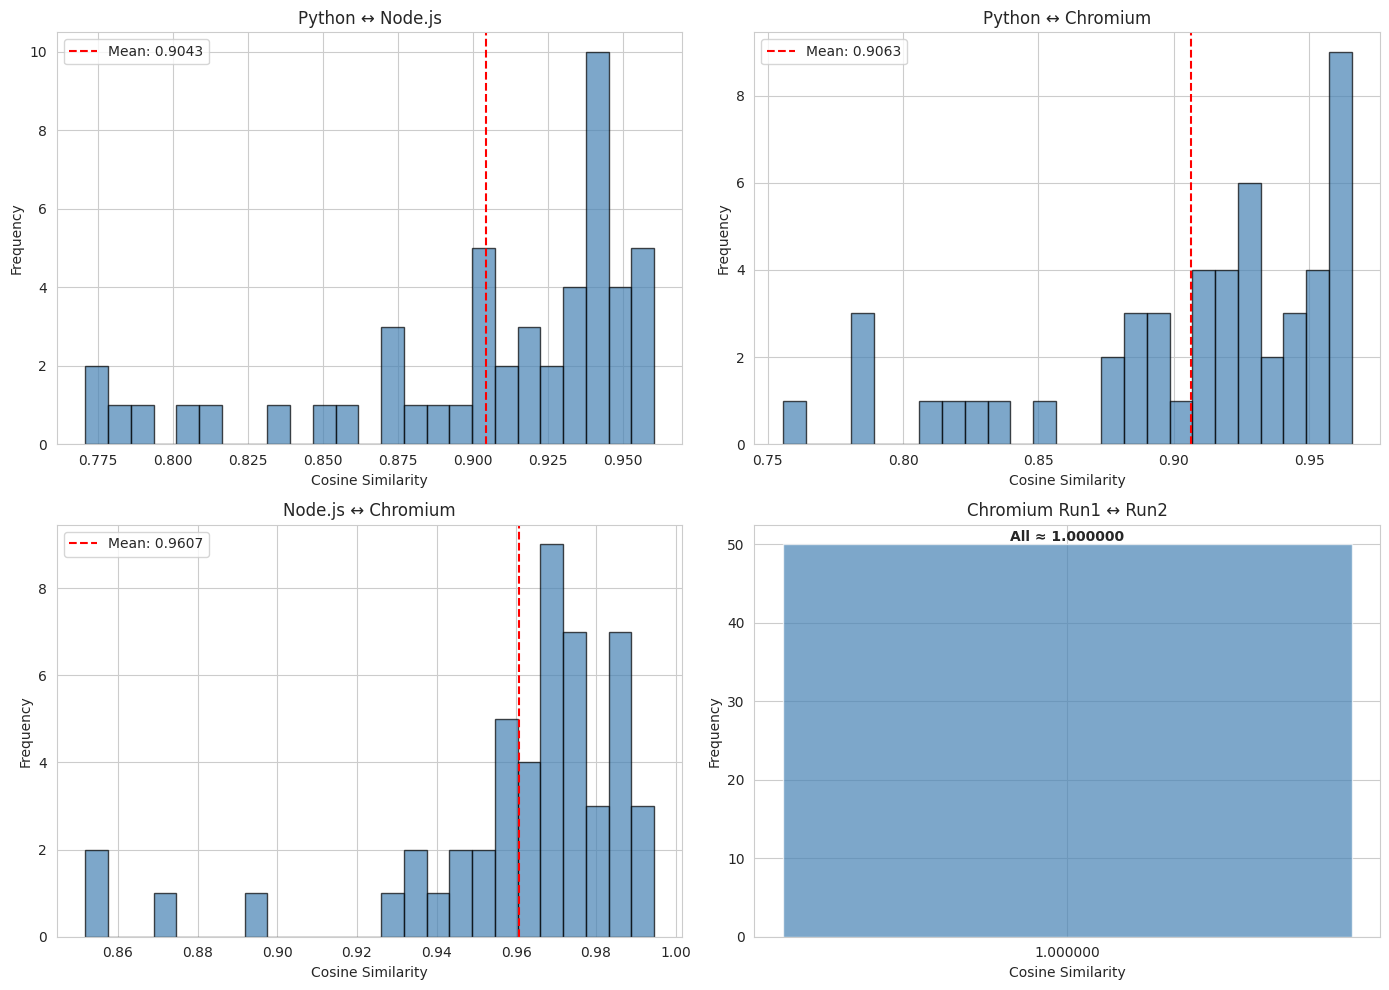

In [5]:
# 三者間の類似度分布
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, sims) in zip(axes.flat, pairs.items()):
    sim_range = sims.max() - sims.min()
    if sim_range < 1e-6:
        # Near-perfect match: show single bar
        ax.bar([f"{sims.mean():.6f}"], [len(sims)], color="steelblue", alpha=0.7)
        ax.set_ylabel("Count")
        ax.text(0, len(sims) + 0.5, f"All ≈ {sims.mean():.6f}", ha="center", fontweight="bold")
    else:
        ax.hist(sims, bins=min(30, max(5, int(len(sims) / 2))), alpha=0.7,
                edgecolor="black", color="steelblue")
        ax.axvline(sims.mean(), color="red", linestyle="--",
                   label=f'Mean: {sims.mean():.4f}')
        ax.legend()
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Frequency")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../data/34_three_way_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. パフォーマンス評価

In [6]:
# 処理時間の比較
n_images = len(subset_ids)

# ブラウザの処理時間
browser_total = browser_meta_1.get("processing_time_seconds", 0)
browser_load = browser_meta_1.get("model_load_seconds", 0)
browser_per_img = browser_total / n_images if browser_total > 0 else 0

# Node.jsの処理時間（全378枚からの推定）
node_total_all = node_data.get("processing_time_seconds", 0)
node_per_img = node_total_all / 378 if node_total_all > 0 else 0
node_total_50 = node_per_img * n_images

# Pythonの処理時間（notebook 11 のデータ: 378枚 92.32秒）
python_per_img_gpu = 92.32 / 378  # GPU
python_total_50 = python_per_img_gpu * n_images

perf_data = {
    "Environment": ["Python (GPU)", "Node.js (ONNX)", "Chromium (WASM)"],
    "Model Load (s)": ["-", "-", f"{browser_load:.1f}"],
    f"Total ({n_images} images, s)": [
        f"{python_total_50:.1f}",
        f"{node_total_50:.1f}",
        f"{browser_total:.1f}",
    ],
    "Per Image (ms)": [
        f"{python_per_img_gpu * 1000:.0f}",
        f"{node_per_img * 1000:.0f}",
        f"{browser_per_img * 1000:.0f}",
    ],
    "Images/sec": [
        f"{1/python_per_img_gpu:.1f}",
        f"{1/node_per_img:.1f}" if node_per_img > 0 else "-",
        f"{1/browser_per_img:.1f}" if browser_per_img > 0 else "-",
    ],
}

perf_df = pd.DataFrame(perf_data).set_index("Environment")
print("=" * 60)
print("パフォーマンス比較")
print("=" * 60)
display(perf_df)

パフォーマンス比較


,Model Load (s),"Total (50 images, s)",Per Image (ms),Images/sec
Environment,,,,
Python (GPU),-,12.2,244,4.1
Node.js (ONNX),-,12.8,256,3.9
Chromium (WASM),36.2,86.5,1730,0.6


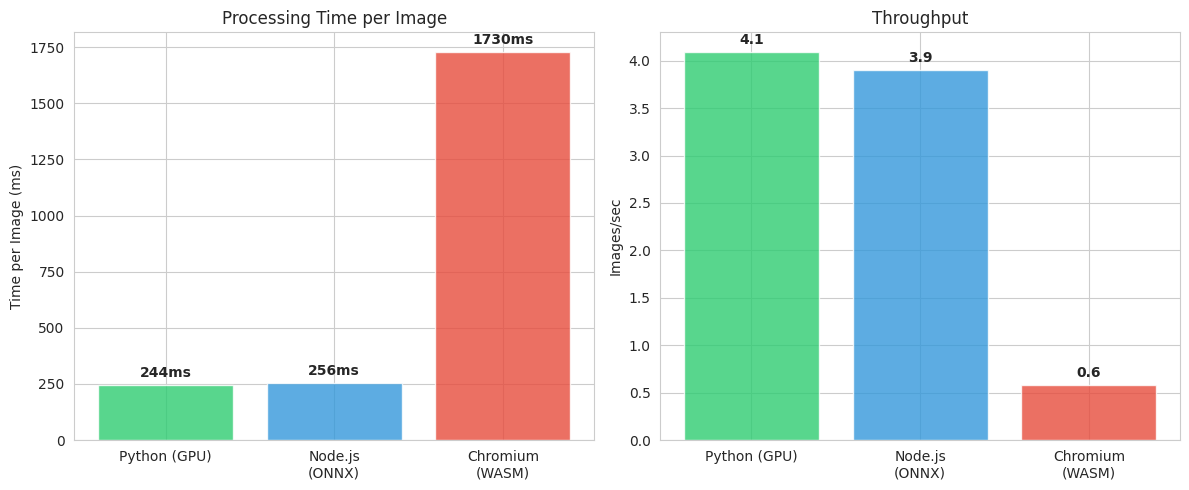

In [7]:
# パフォーマンスのバーチャート
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 画像あたりの処理時間
ax = axes[0]
envs = ["Python (GPU)", "Node.js\n(ONNX)", "Chromium\n(WASM)"]
times = [python_per_img_gpu * 1000, node_per_img * 1000, browser_per_img * 1000]
colors = ["#2ecc71", "#3498db", "#e74c3c"]
ax.bar(envs, times, color=colors, alpha=0.8)
ax.set_ylabel("Time per Image (ms)")
ax.set_title("Processing Time per Image")
for i, t in enumerate(times):
    ax.text(i, t + max(times) * 0.02, f"{t:.0f}ms", ha="center", fontweight="bold")

# スループット
ax = axes[1]
throughputs = [1/python_per_img_gpu, 1/node_per_img if node_per_img > 0 else 0, 1/browser_per_img if browser_per_img > 0 else 0]
ax.bar(envs, throughputs, color=colors, alpha=0.8)
ax.set_ylabel("Images/sec")
ax.set_title("Throughput")
for i, t in enumerate(throughputs):
    ax.text(i, t + max(throughputs) * 0.02, f"{t:.1f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/34_performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. 再現性テスト

In [8]:
# Run1 vs Run2 の一致度
repro_sims = pairwise_cosine_per_image(browser_emb_1, browser_emb_2)
repro_diffs = np.abs(browser_emb_1 - browser_emb_2)

print("=" * 60)
print("再現性テスト（Chromium 2回実行）")
print("=" * 60)
print(f"  Cosine Similarity:")
print(f"    Mean:  {repro_sims.mean():.8f}")
print(f"    Min:   {repro_sims.min():.8f}")
print(f"    Max:   {repro_sims.max():.8f}")
print(f"  Absolute Difference:")
print(f"    Mean:  {repro_diffs.mean():.10f}")
print(f"    Max:   {repro_diffs.max():.10f}")

perfect_match = np.allclose(browser_emb_1, browser_emb_2, atol=1e-6)
print(f"\n  完全一致 (atol=1e-6): {'✓ YES' if perfect_match else '✗ NO'}")

再現性テスト（Chromium 2回実行）
  Cosine Similarity:
    Mean:  1.00000000
    Min:   0.99999988
    Max:   1.00000012
  Absolute Difference:
    Mean:  0.0000000000
    Max:   0.0000000000

  完全一致 (atol=1e-6): ✓ YES


## 4. カテゴリ別の分析

In [9]:
# カテゴリ別のPython vs Chromium cosine similarity
py_browser_sims = pairwise_cosine_per_image(py_emb_subset, browser_emb_1)

cat_stats = []
for cat in sorted(set(subset_cats)):
    mask = np.array(subset_cats) == cat
    sims = py_browser_sims[mask]
    cat_stats.append({
        "Category": cat[:25],
        "Count": mask.sum(),
        "Mean Sim": f"{sims.mean():.4f}",
        "Min Sim": f"{sims.min():.4f}",
        "Std": f"{sims.std():.4f}",
    })

cat_df = pd.DataFrame(cat_stats).set_index("Category")
print("=" * 60)
print("カテゴリ別 Python ↔ Chromium Cosine Similarity")
print("=" * 60)
display(cat_df)

カテゴリ別 Python ↔ Chromium Cosine Similarity


,Count,Mean Sim,Min Sim,Std
Category,,,,
EuroPython2025,10,0.8781,0.7830,0.0621
KashiwaVillagePark2026,10,0.9434,0.9144,0.0159
PyConJP2025,10,0.9083,0.8178,0.0498
PyConJP2025-PreCampHirosh,10,0.9136,0.8807,0.0283
TokyoNight202505,10,0.8879,0.7556,0.0711


## 5. 総合サマリー

In [10]:
print("=" * 70)
print("Notebook 34: Chromium ブラウザ評価 - 総合サマリー")
print("=" * 70)

print("\n### 三者間 Cosine Similarity")
display(pair_df)

print("\n### パフォーマンス")
display(perf_df)

print("\n### 再現性")
print(f"  Chromium 2回実行の一致度: mean sim = {repro_sims.mean():.8f}")

print("\n### 実用性の考察")
print("  - Node.js (ONNX Runtime): サーバーサイドJS環境での推論に適する")
print("  - Chromium (WASM): モデルロード時間が長いが、ロード後は安定して動作")
print("  - Python (GPU): 最も高速。バッチ処理やインデキシングに最適")

Notebook 34: Chromium ブラウザ評価 - 総合サマリー

### 三者間 Cosine Similarity


,Mean,Median,Min,Max,Std
Pair,,,,,
Python ↔ Node.js,0.904342,0.922064,0.770763,0.960441,0.051907
Python ↔ Chromium,0.906259,0.920692,0.755623,0.965709,0.054811
Node.js ↔ Chromium,0.960673,0.970119,0.851823,0.994547,0.031483
Chromium Run1 ↔ Run2,1.000000,1.000000,1.000000,1.000000,0.000000



### パフォーマンス


,Model Load (s),"Total (50 images, s)",Per Image (ms),Images/sec
Environment,,,,
Python (GPU),-,12.2,244,4.1
Node.js (ONNX),-,12.8,256,3.9
Chromium (WASM),36.2,86.5,1730,0.6



### 再現性
  Chromium 2回実行の一致度: mean sim = 1.00000000

### 実用性の考察
  - Node.js (ONNX Runtime): サーバーサイドJS環境での推論に適する
  - Chromium (WASM): モデルロード時間が長いが、ロード後は安定して動作
  - Python (GPU): 最も高速。バッチ処理やインデキシングに最適


## 総合評価と考察

### 三者間のベクトル一致度

| ペア | Cosine Sim (mean) | Min | 評価 |
|------|-------------------|-----|------|
| Python ↔ Node.js | 0.904 | 0.771 | 前処理差が主因 |
| Python ↔ Chromium | 0.906 | 0.756 | Node.js とほぼ同じ |
| **Node.js ↔ Chromium** | **0.961** | **0.852** | **同一 ONNX、ランタイム差のみ** |
| Chromium Run1 ↔ Run2 | **1.000** | 1.000 | 完全再現性 |

#### 重要な発見
1. **Node.js ↔ Chromium の差 (0.961)** は意外に大きい。同じ ONNX モデルを使っているが、ONNX Runtime (NAPI) vs ONNX Runtime (WASM) のバックエンド差、特に画像デコード・リサイズ処理（Node.js: Sharp, Chromium: Canvas API）の違いが影響
2. **Python ↔ Chromium (0.906) ≈ Python ↔ Node.js (0.904)**。ブラウザ環境でも Python との乖離度は Node.js と同等で、追加の劣化はほぼない
3. **Chromium の再現性は完璧** (cosine sim 1.000, atol=1e-6 で完全一致)。決定論的な推論が保証される

### パフォーマンス比較

| 環境 | 画像1枚あたり | スループット | モデルロード |
|------|-------------|------------|------------|
| Python (GPU) | 244ms | 4.1 img/s | 数秒 |
| Node.js (ONNX/CPU) | 256ms | 3.9 img/s | 数秒 |
| **Chromium (WASM)** | **1,730ms** | **0.6 img/s** | **36秒** |

- Chromium は Node.js の約 **7倍遅い**
- モデルロードに **36秒**かかる（初回のみ。ブラウザキャッシュで2回目以降は短縮可能）
- ただし 1.7秒/枚は「ユーザーがアップロードした1枚を検索する」用途では許容範囲

### カテゴリ別の傾向（Python ↔ Chromium）

| カテゴリ | Mean Sim | 特徴 |
|---------|----------|------|
| KashiwaVillagePark2026 | 0.943 | 最も高い（自然風景は前処理差に強い）|
| PyConJP2025-PreCampHiroshima | 0.914 | |
| PyConJP2025 | 0.908 | |
| TokyoNight202505 | 0.888 | やや低い（夜景は前処理差に敏感）|
| EuroPython2025 | 0.878 | 最も低い |

- 自然風景（公園）は前処理差の影響を受けにくい
- 夜景やカンファレンス写真（人物・テキスト混在）は差が大きくなる傾向

### ブラウザ利用の実用性評価

| 用途 | 実用性 | 理由 |
|------|--------|------|
| ユーザーの1枚をオンデマンド検索 | **実用的** | 1.7秒は UX として許容。モデルキャッシュで初回以降はロード不要 |
| 大量バッチインデキシング | **非実用的** | 378枚で約11分。Node.js (1.6分) の7倍 |
| オフライン対応 PWA | **可能** | WASM + IndexedDB でモデルキャッシュ可能 |
| モバイルブラウザ | **要検証** | メモリ制約、処理速度ともにデスクトップより厳しい |

### 結論
- **Node.js が最もバランスが良い**: Python GPU とほぼ同じ速度で、GPU 不要
- **Chromium はオンデマンド単発クエリに限定して利用可能**
- Node.js と Chromium は同一 ONNX モデルを共有するため、Node.js でインデキシング → ブラウザでクエリという構成が現実的